# Feature Distribution Vs Distance From Camera

Video recording is done by Hedi at different distances from the camera

In [1]:
import pandas as pd
import os
import re
import datetime as dt

In [2]:
directory = r"\\optalert-nb128\sandbox\Stonkam\hz_Stonkam_csvs_2026_01_29"
disance_file_name = 'recording_registry.txt'

In [3]:
file_path = f"{directory}/{disance_file_name}"

with open(file_path, "r", encoding="utf-8") as f:
    content = f.read()

In [4]:
# Regex pattern to capture each recording block
pattern = re.compile(
    r"## Distance\s+(?P<distance>\d+)cm\s*"
    r"Calibration timestamp\s+(?P<calibration>.+?)\s*"
    r"Start\s+(?P<start>.+?)\s*"
    r"End\s+(?P<end>.+?)(?:\n|$)",
    re.MULTILINE
)

records = []

In [5]:
import re
import pandas as pd

records = []

for match in pattern.finditer(content):
    records.append({
        "Distance_cm": int(match.group("distance")),
        "Calibration_timestamp": match.group("calibration").strip(),
        "Start": match.group("start").strip(),
        "End": match.group("end").strip(),
    })

df_distances = pd.DataFrame(records)

# Explicit format including timezone offset
dt_format = "%d-%m-%Y %H:%M:%S%z"

df_distances["Calibration_timestamp"] = pd.to_datetime(
    df_distances["Calibration_timestamp"],
    format=dt_format
)

df_distances["Start"] = pd.to_datetime(
    df_distances["Start"],
    format=dt_format
)

df_distances["End"] = pd.to_datetime(
    df_distances["End"],
    format=dt_format
)

df_distances = df_distances.sort_values("Start").reset_index(drop=True)
df_distances["Calibration_timestamp"] = df_distances["Calibration_timestamp"].dt.floor("min")
df_distances["Start"] = df_distances["Start"].dt.floor("min")
df_distances["End"] = df_distances["End"].dt.floor("min")
df_distances

,Distance_cm,Calibration_timestamp,Start,End
0,57,2026-01-30 11:32:00+11:00,2026-01-30 11:32:00+11:00,2026-01-30 11:43:00+11:00
1,100,2026-01-30 11:45:00+11:00,2026-01-30 11:48:00+11:00,2026-01-30 11:58:00+11:00
2,50,2026-02-02 15:00:00+11:00,2026-02-02 15:00:00+11:00,2026-02-02 15:10:00+11:00
3,60,2026-02-02 15:15:00+11:00,2026-02-02 15:15:00+11:00,2026-02-02 15:25:00+11:00
4,70,2026-02-02 15:27:00+11:00,2026-02-02 15:27:00+11:00,2026-02-02 15:37:00+11:00
5,80,2026-02-02 15:40:00+11:00,2026-02-02 15:40:00+11:00,2026-02-02 15:50:00+11:00
6,90,2026-02-02 15:51:00+11:00,2026-02-02 15:52:00+11:00,2026-02-02 16:02:00+11:00


In [6]:
import os
import re
import pandas as pd

all_data = []

# Regex to extract timestamp like: 2026-01-30_1148
folder_pattern = re.compile(r"_(\d{4}-\d{2}-\d{2})_(\d{4})")

for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    match = folder_pattern.search(folder)
    if not match:
        continue
    
    date_part = match.group(1)          # 2026-01-30
    time_part = match.group(2)          # 1148
    
    tz = df_distances["Start"].dt.tz

    folder_timestamp = pd.to_datetime(
        f"{date_part} {time_part[:2]}:{time_part[2:]}",
        format="%Y-%m-%d %H:%M"
    ).tz_localize(tz)

    stats_file = os.path.join(folder_path, "summary_stats.csv")
    if not os.path.exists(stats_file):
        continue
    
    df_stats = pd.read_csv(stats_file)
    
    # Add extracted timestamp
    df_stats["Folder_timestamp"] = folder_timestamp
    
    # Find matching Distance based on Start–End range
    match_distance = df_distances[
        (df_distances["Start"] <= folder_timestamp) &
        (df_distances["End"] >= folder_timestamp)
    ]
    
    if not match_distance.empty:
        df_stats["Distance_cm"] = match_distance.iloc[0]["Distance_cm"]
    else:
        df_stats["Distance_cm"] = None
    
    all_data.append(df_stats)

# Combine everything
final_df = pd.concat(all_data, ignore_index=True)

final_df.dropna(subset=["Distance_cm"], inplace=True)

C:\Users\VJain\AppData\Local\Temp\ipykernel_28752\1619644693.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(all_data, ignore_index=True)


In [7]:
# import model configs
jds_config = pd.read_csv(r"C:\Users\VJain\Optalert Australia\R&D - 5-R&D\530-Investigations\530-150 Video-based Drowsiness Models Evaluation\config\model_configs.csv")
jds_config = jds_config.set_index('variable')
# jds_config

In [8]:
features_model_11 = jds_config[jds_config['model_11'] != 0].index.tolist()
features_model_11 = [_ for _ in features_model_11 if _ != 'Constant']
features_model_11

['LnMeanPositiveZCI',
 'LnMeanNegativeAVR',
 'LnStdDevNegativeAVR',
 'LnStdDevAVRProduct',
 'LnMeanBTD']

In [9]:
final_df.columns = final_df.columns.str.strip()

In [10]:
# Suppose you want to fix all columns except "Distance_cm" (or specify your float features)
float_cols = [col for col in features_model_11 if col != "Distance_cm"]

for col in float_cols:
    # Convert strings to floats, coerce errors (like ' nan') to actual NaN
    final_df[col] = pd.to_numeric(final_df[col].str.strip(), errors='coerce')

C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\VJain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values t

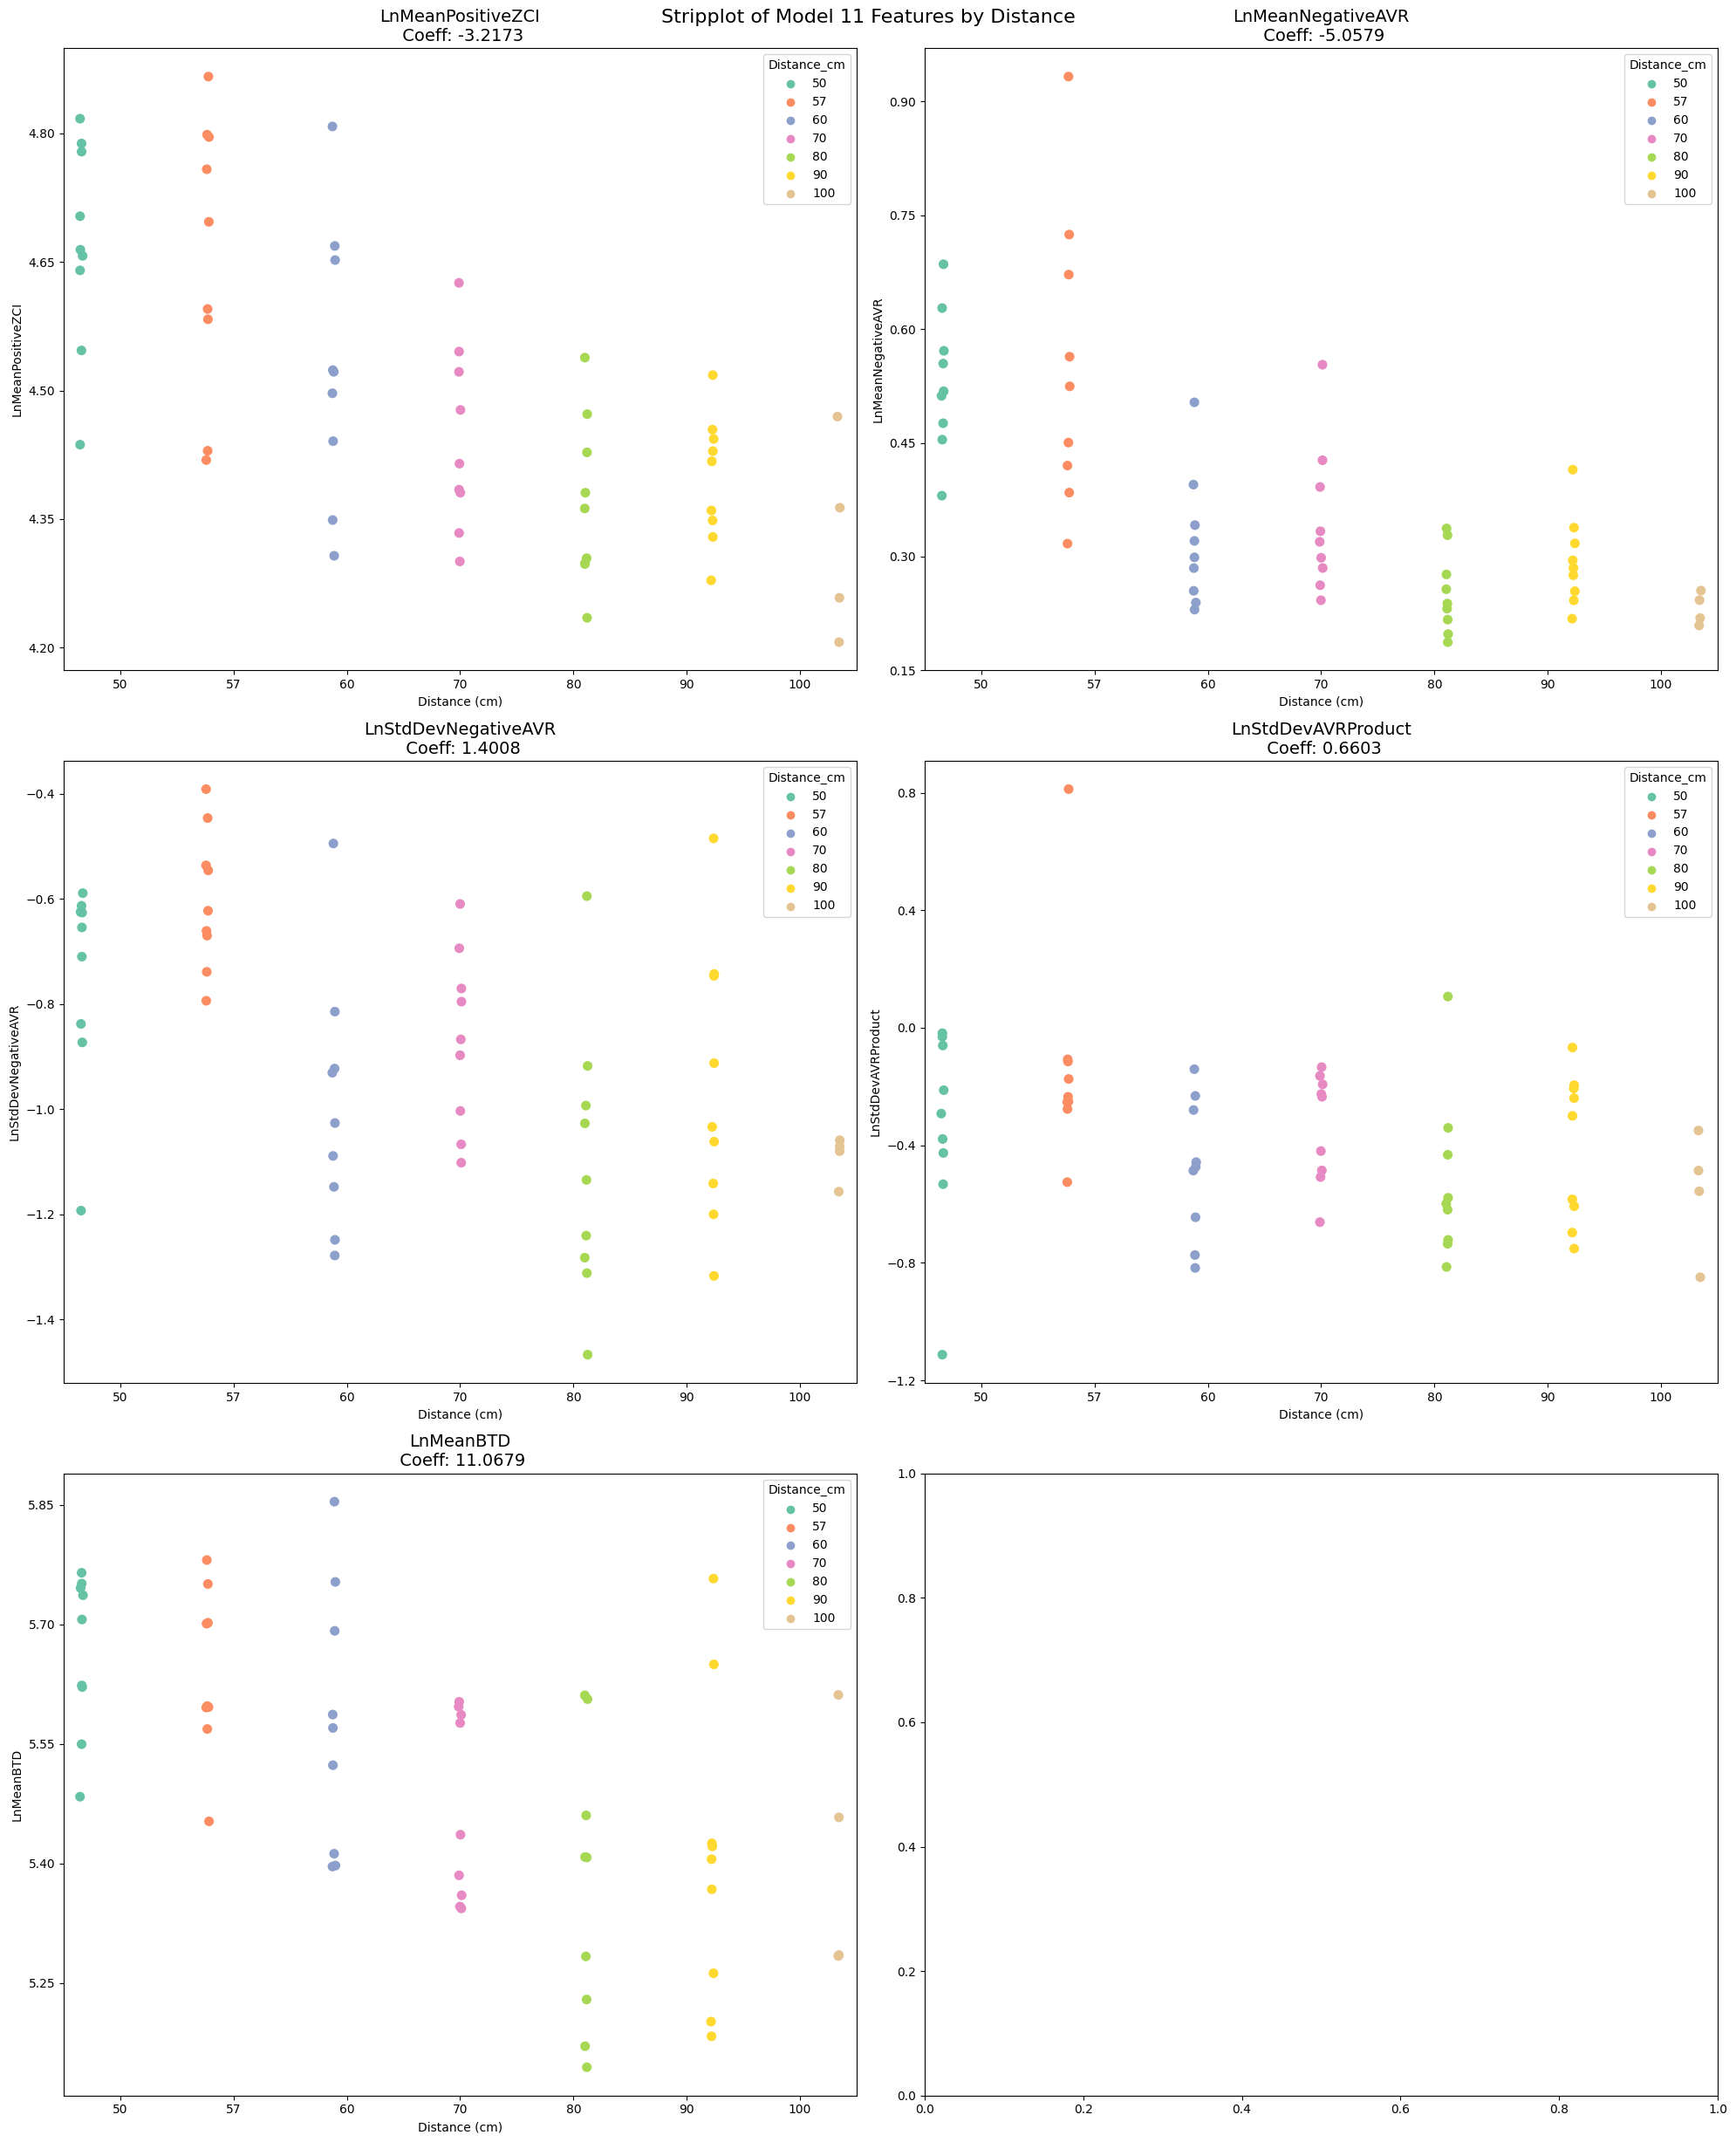

In [11]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(20, 25))
axes = axes.flatten()

for i, feature in enumerate(features_model_11):
    sns.stripplot(x="Distance_cm", y=feature, data=final_df, ax=axes[i], hue="Distance_cm", palette="Set2", dodge=True, jitter=True, size=8)
    
    axes[i].set_title(f"{feature}\n Coeff: {jds_config.loc[feature, 'model_11']:.4f}", fontsize=14)
    axes[i].set_xlabel("Distance (cm)")
    axes[i].set_ylabel(feature)
    
    # 🔥 Limit number of y-axis ticks
    axes[i].yaxis.set_major_locator(ticker.MaxNLocator(6))


plt.suptitle("Stripplot of Model 11 Features by Distance", fontsize=16)
plt.tight_layout()

In [12]:
jds_config[jds_config['model_11'] != 0]

,model_10,model_11
variable,,
Constant,-10.877890,-41.1825
LnMeanPositiveZCI,0.000000,-3.2173
LnMeanNegativeAVR,0.000000,-5.0579
LnStdDevNegativeAVR,0.000000,1.4008
LnStdDevAVRProduct,-0.402946,0.6603
LnMeanBTD,0.000000,11.0679


In [2]:
import pandas as pd
path = r"\\optalert-nb128\sandbox\Stonkam\hz_Stonkam_csvs_2026_01_29\2026_02_26_14_55_CSVs\eyelibOld.csv"
df = pd.read_csv(path)
df.columns

Index(['1772066195782678', '33333', '0.350000', '0', '0.350000.1', '0.1'], dtype='object')

In [3]:
import pandas as pd

df = pd.read_csv(path, header=None)  # Tell pandas there is no header
df.columns = ["col1", "col2", "col3", "col4", "col5", "col6"]  # Replace with your actual column names

In [4]:
df_valid = df[df['col4'] == 1]
df_valid["col1"] -= df_valid["col1"].min()  # Normalize to start at 0
len(df_valid)

C:\Users\VJain\AppData\Local\Temp\ipykernel_14460\4111186286.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["col1"] -= df_valid["col1"].min()  # Normalize to start at 0


56683

## problem. need to convert the values from string to float first

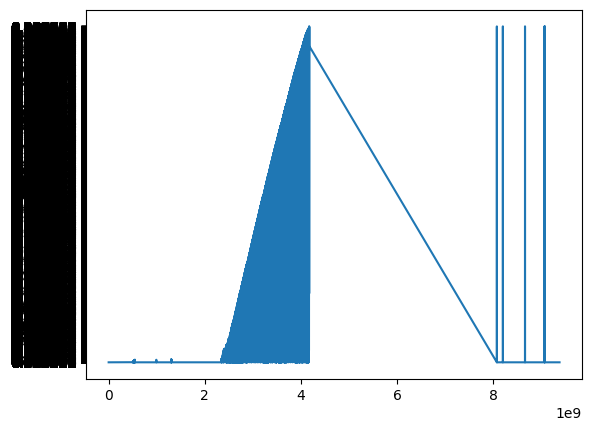

In [7]:
import matplotlib.pyplot as plt
df_valid_plot = df_valid
plt.plot(df_valid_plot['col1'], df_valid_plot['col3'])

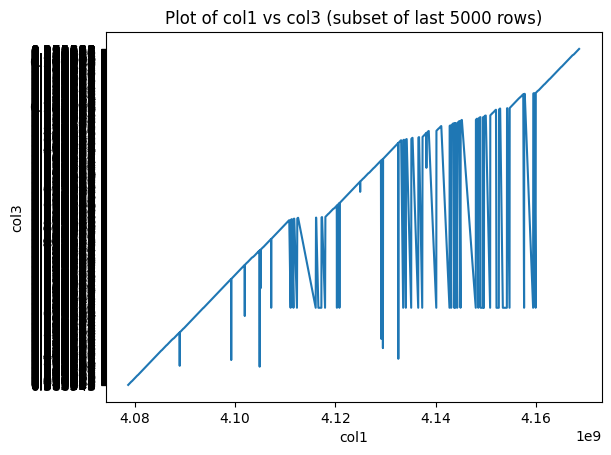

In [13]:
subset = df_valid.iloc[-5000:-3000]  # same as tail(5000).head(2000)
plt.plot(subset['col1'], subset['col3'])
plt.xlabel('col1')
plt.ylabel('col3')
plt.title('Plot of col1 vs col3 (subset of last 5000 rows)')
plt.show()

In [16]:
df_valid

,col1,col2,col3,col4,col5,col6
1054,0,66681,0.350000,1,0.350000,1
1055,33320,33320,0.350000,1,0.350000,1
1056,99988,66668,0.350000,1,0.350000,1
1057,133323,33335,0.350000,1,0.350000,1
1058,199993,66670,0.350000,1,0.350000,1
...,...,...,...,...,...,...
113839,9375459028,66671,0.350000,1,0.350000,1
113920,9379225701,33341,0.350000,1,0.350000,1
113921,9379292359,66658,0.350000,1,0.350000,1
113974,9381759030,66669,0.350000,1,0.350000,1
